<div style="background-color: lightblue; color: black; border: 2px solid black; 
padding: 15px 25px; border-radius: 8px; margin: 10px 0px;">

  <h2 style="color: black; margin: 0px 0px 10px 0px;">
   Rain gauge optimisation
  </h2>

  <hr style="border: 1px solid black; margin: 10px 0px;">

  <p>This code works on defining optimal locations for placements of new rain gauges in the Upper Severn catchment. The placement of the gauges aims to optimise the accuracy with which rainfall over the catchment can be predicted. </p>

  <p><strong>The following data is available:</strong></p>
  <ul>
    <li> 1km HAD-UK gridded annual (?) rainfall data </li>
    <li> Rain gauge data from 10? existing rain gauges</li>
    <li> 30m (?) DEM data: from which slope and aspect can be derived. These are then aggregated to 1km </li>      
  </ul>
<!-- 
  <div style="background-color: white; border-left: 4px solid orange; 
  padding: 8px 15px; border-radius: 0px 5px 5px 0px; margin-top: 12px;">
    <strong>NB:</strong> The threshold for an "unphysical" value is 
    currently set at <strong>150mm/hr</strong> — selected relatively 
    arbitrarily and may need review.
  </div> -->

</div>

In [1]:
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import pickle
import rioxarray
import xarray as xr
from pathlib import Path
from rasterio.enums import Resampling
from rasterio.features import rasterize
from shapely.geometry import box
import copy
from rasterstats import zonal_stats
import importlib
import time

# import random
import functions
importlib.reload(functions)
from functions import *

data_dir = "/scratch/hydro4/users/kv25483/FDRI/Rain_gauge_optimisation/Data/"

In [2]:
import glob
import iris

year = 1991

filenames=[]

for year in range(1993,1994):
    general_filename = data_dir + f'CEH-GEAR-1km/CEH-GEAR-1hr-v2_{year}*'
    for filename in glob.glob(general_filename):
        filenames.append(filename)
print(len(filenames))

monthly_cubes_list = iris.load(filenames)

rain_cubes = [c for c in monthly_cubes_list if c.name() == 'rainfall_amount']
rain_cubes = iris.cube.CubeList(rain_cubes)
obs_cube = rain_cubes[0]

cubes = iris.load(filenames)

rain_cubes = iris.cube.CubeList([c for c in cubes if c.name() == 'rainfall_amount'])

for c in rain_cubes:
    c.attributes = {}   # 🔥 remove all conflicting attributes

obs_cube = rain_cubes.concatenate_cube()

12


/home/kv25483/anaconda3/envs/geo_env2/lib/python3.10/site-packages/iris/__init__.py:680: FutureWarning: Ignoring a datum in netCDF load for consistency with existing behaviour. In a future version of Iris, this datum will be applied. To apply the datum when loading, use the iris.FUTURE.datum_support flag.
  cubes = _load_collection(uris, constraints, callback).combined().cubes()


In [3]:
catchment = gpd.read_file(data_dir + "54080/54080.shp")

In [4]:
from pyproj import Transformer
def trim_to_bbox_of_region_obs(obs_cube, gdf, y_coord, x_coord, buffer_km=0):

    import numpy as np
    from pyproj import Transformer

    minmax = lambda x: (np.min(x), np.max(x))

    # ---------------------------
    # Grid coordinates (BNG)
    # ---------------------------
    lats_1d = obs_cube.coord(y_coord).points
    lons_1d = obs_cube.coord(x_coord).points

    lons_2d, lats_2d = np.meshgrid(lons_1d, lats_1d)

    # ---------------------------
    # Convert to WGS84 (your current approach)
    # ---------------------------
    transformer = Transformer.from_crs("EPSG:27700", "EPSG:4326", always_xy=True)
    lons_2d, lats_2d = transformer.transform(lons_2d, lats_2d)

    # ---------------------------
    # Catchment to WGS84
    # ---------------------------
    gdf = gdf.to_crs("EPSG:4326")
    bbox = gdf.total_bounds  # [minx, miny, maxx, maxy]

    # ---------------------------
    # BUFFER (NEW PART)
    # ---------------------------
    # convert km → degrees approx via projected buffer (better: do in EPSG:27700 ideally)
    buffer_deg = buffer_km / 111.0

    minx, miny, maxx, maxy = bbox
    bbox = (minx - buffer_deg, miny - buffer_deg, maxx + buffer_deg, maxy + buffer_deg)

    # ---------------------------
    # mask grid
    # ---------------------------
    inregion = ((lons_2d > bbox[0]) & (lons_2d < bbox[2]) & (lats_2d > bbox[1]) & (lats_2d < bbox[3]))

    region_inds = np.where(inregion)

    imin, imax = minmax(region_inds[0])
    jmin, jmax = minmax(region_inds[1])

    obs_cube = obs_cube[..., imin:imax+1, jmin:jmax+1]

    return obs_cube

obs_cube_trimmed = trim_to_bbox_of_region_obs(obs_cube, catchment, 'projection_y_coordinate', 'projection_x_coordinate',
                                             1)

In [39]:
data = obs_cube_trimmed.data  # (time, y, x)
mean_hourly = np.nanmean(data, axis=0)

wet_data = np.where(data > 0, data, np.nan)
mean_wet_hourly = np.nanmean(wet_data, axis=0)
    
# import iris
# import iris.cube

# mean_hourly_cube = iris.cube.Cube(mean_hourly,long_name="mean_hourly_rainfall",units=obs_cube_trimmed.units)

# mean_wet_cube = iris.cube.Cube(mean_wet_hourly,long_name="mean_wet_hourly_rainfall",units=obs_cube_trimmed.units)

In [40]:
import iris.coords as icoords

y = obs_cube_trimmed.coord('projection_y_coordinate')
x = obs_cube_trimmed.coord('projection_x_coordinate')

mean_hourly_cube = iris.cube.Cube(mean_hourly, var_name="mean_hourly_rainfall",units=obs_cube_trimmed.units,
                                  dim_coords_and_dims=[(y.copy(), 0), (x.copy(), 1)])

mean_wet_cube = iris.cube.Cube(mean_wet_hourly, var_name="mean_hourly_wet_rainfall",units=obs_cube_trimmed.units,
                                  dim_coords_and_dims=[(y.copy(), 0), (x.copy(), 1)])

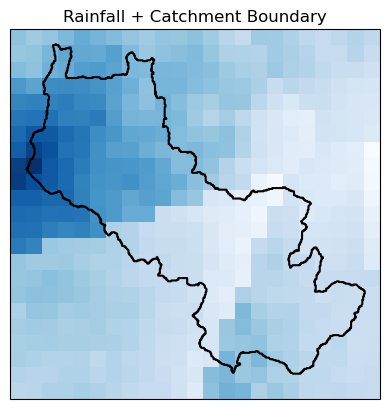

In [41]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import iris.plot as iplt

fig = plt.figure()
ax = plt.axes(projection=ccrs.OSGB())  # IMPORTANT: match your cube CRS

# --- plot rainfall slice ---
iplt.pcolormesh(mean_wet_cube,axes=ax, cmap='Blues')
# --- add catchment boundary ---
catchment.boundary.plot(ax=ax, edgecolor='black',linewidth=1.5, transform=ccrs.OSGB())
ax.coastlines(resolution='10m')
ax.set_title("Rainfall + Catchment Boundary")

plt.show()

In [41]:
# catchment = gpd.read_file(data_dir + "54080/54080.shp")
# print(catchment.crs)
# print(obs_cube.coord_system())

# import xarray as xr

# da = xr.DataArray.from_iris(obs_cube)

# import numpy as np

# x = obs_cube.coord('projection_x_coordinate').points
# y = obs_cube.coord('projection_y_coordinate').points

# xx, yy = np.meshgrid(x, y)

# geom = catchment.geometry.unary_union
# from shapely import vectorized

# mask = vectorized.contains(geom, xx, yy)

# data = obs_cube.data  # shape: (time, y, x)

# masked_data = np.where(mask, data, np.nan)

# mean_hourly = np.nanmean(masked_data, axis=0)

EPSG:27700
TransverseMercator(latitude_of_projection_origin=49.0, longitude_of_central_meridian=-2.0, false_easting=400000.0, false_northing=-100000.0, scale_factor_at_central_meridian=0.9996012717, ellipsoid=GeogCS(semi_major_axis=6377563.396, semi_minor_axis=6356256.909237285))


/tmp/ipykernel_1758114/3527008647.py:16: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  geom = catchment.geometry.unary_union
/tmp/ipykernel_1758114/3527008647.py:19: DeprecationWarning: The 'shapely.vectorized.contains' function is deprecated and will be removed a future version. Use 'shapely.contains_xy' instead (available since shapely 2.0.0).
  mask = vectorized.contains(geom, xx, yy)
/tmp/ipykernel_1758114/3527008647.py:25: RuntimeWarning: Mean of empty slice
  mean_hourly = np.nanmean(masked_data, axis=0)


In [46]:
from pyproj import Proj, transform
def trim_to_bbox_of_region_obs (obs_cube, gdf, y_coord, x_coord):

    # CReate function to find   
    minmax = lambda x: (np.min(x), np.max(x))
    
    #### Find the lats and lons of the cube in BNG
    lats_1d = obs_cube.coord(y_coord).points
    lons_1d = obs_cube.coord(x_coord).points
    
    # Convert to 2D
    lons_2d, lats_2d = np.meshgrid(lons_1d, lats_1d)
    
    # Convert to WGS84
    lons_2d ,lats_2d= transform(Proj(init='epsg:27700'),
                                      Proj(init='epsg:4326'),
                                      lons_2d,lats_2d)
    
    # Convert the regional gdf to WGS84 (same as cube)
    gdf = gdf.to_crs({'init' :'epsg:4326'}) 
    # Find the bounding box of the region
    bbox = gdf.total_bounds
    
    inregion = np.logical_and(np.logical_and(lons_2d > bbox[0],
                                             lons_2d < bbox[2]),
                              np.logical_and(lats_2d > bbox[1],
                                             lats_2d < bbox[3]))
    region_inds = np.where(inregion)
    imin, imax = minmax(region_inds[0])
    jmin, jmax = minmax(region_inds[1])
    
    obs_cube = obs_cube[..., imin:imax+1, jmin:jmax+1]
    
    return obs_cube

obs_cube_trimmed = trim_to_bbox_of_region_obs(obs_cube, catchment, 'projection_y_coordinate', 'projection_x_coordinate')

/home/kv25483/anaconda3/envs/geo_env2/lib/python3.10/site-packages/pyproj/crs/crs.py:143: FutureWarning: '+init=<authority>:<code>' syntax is deprecated. '<authority>:<code>' is the preferred initialization method. When making the change, be mindful of axis order changes: https://pyproj4.github.io/pyproj/stable/gotchas.html#axis-order-changes-in-proj-6
  in_crs_string = _prepare_from_proj_string(in_crs_string)
/home/kv25483/anaconda3/envs/geo_env2/lib/python3.10/site-packages/pyproj/crs/crs.py:143: FutureWarning: '+init=<authority>:<code>' syntax is deprecated. '<authority>:<code>' is the preferred initialization method. When making the change, be mindful of axis order changes: https://pyproj4.github.io/pyproj/stable/gotchas.html#axis-order-changes-in-proj-6
  in_crs_string = _prepare_from_proj_string(in_crs_string)
/tmp/ipykernel_1758114/2050095545.py:15: FutureWarning: This function is deprecated. See: https://pyproj4.github.io/pyproj/stable/gotchas.html#upgrading-to-pyproj-2-from-py

/tmp/ipykernel_1758114/3375419696.py:1: RuntimeWarning: Mean of empty slice
  mean_hourly = np.nanmean(masked_data, axis=0)


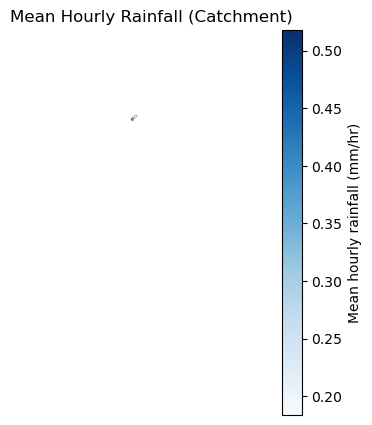

In [43]:
mean_hourly = np.nanmean(masked_data, axis=0)

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6,5))

im = ax.imshow(mean_hourly, origin='lower', cmap='Blues')

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Mean hourly rainfall (mm/hr)")

ax.set_title("Mean Hourly Rainfall (Catchment)")
ax.axis('off')

plt.show()

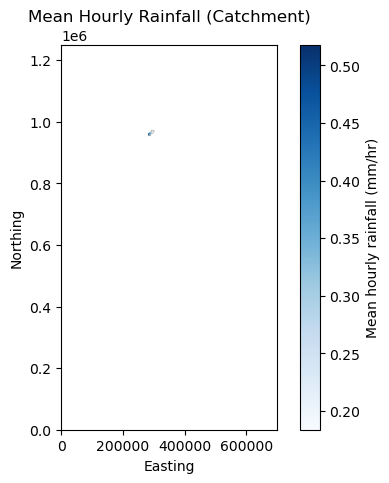

In [44]:
x = obs_cube.coord('projection_x_coordinate').points
y = obs_cube.coord('projection_y_coordinate').points

fig, ax = plt.subplots(figsize=(6,5))

im = ax.imshow(
    mean_hourly,
    origin='lower',
    cmap='Blues',
    extent=[x.min(), x.max(), y.min(), y.max()]
)

plt.colorbar(im, ax=ax, label="Mean hourly rainfall (mm/hr)")
ax.set_title("Mean Hourly Rainfall (Catchment)")
ax.set_xlabel("Easting")
ax.set_ylabel("Northing")

plt.show()

In [2]:
# Load Plynlimon catchments shapefile
Plyn_catch = gpd.read_file(data_dir + "Headwater_catchments/Plyn_catchments/data/Shapefile/"
    "ee2eeee5-e456-4e93-87e9-eee97ee149ee/PlynlimonCatchments.shp").set_crs(epsg=27700, allow_override=True)

# Load Plynlimon river network
Plyn_RN = gpd.read_file(data_dir + "Headwater_catchments/Plyn_rivernet/data/Shapefile/PlynlimonRiverNetwork.shp").set_crs(
    epsg=27700, allow_override=True)

# Load 2023 Land Cover data from CEH (10m res)
catchment_LMC = rioxarray.open_rasterio(data_dir + "lmc2023 clip.tif")

# Load DEMs
dem_Dolwen_1m = rioxarray.open_rasterio(data_dir + "dem_Dolwen_1m.tif")
dem_Dolwen    = rioxarray.open_rasterio(data_dir + "dem_Dolwen.tif")
dem_wider     = rioxarray.open_rasterio(data_dir +  "dem_Dolwen_wider.tif")

# Load other shapefiles
catchment_Dolwen = gpd.read_file(data_dir + "54080/54080.shp")
river_net_wider = gpd.read_file(data_dir + "54080_river_net/StreamLine_54080.shp").set_crs(epsg=27700)
river_net_Dolwen = gpd.read_file(data_dir + "river_net_Dolwen.shp")
river_net_CEH = gpd.read_file(data_dir + "River_net/DigitalRiverNetwork_50K_GB.shp").set_crs(epsg=27700)

# ==============================================================
# Load Soil Info
# ==============================================================
BGS_soil_shp = gpd.read_file(data_dir + "BGS_soil_parent.shp")

# Load and reproject HOST raster to EPSG:27700
BGS_HOST = rioxarray.open_rasterio(data_dir + "HOST.tif")
BGS_HOST = BGS_HOST.rio.reproject("EPSG:27700")

# Clip soil polygon to Dolwen catchment
BGS_soil_Dolwen = gpd.overlay(BGS_soil_shp, catchment_Dolwen, how="intersection")

# Mask HOST raster to Dolwen catchment
BGS_HOST_Dolwen = BGS_HOST.rio.clip(catchment_Dolwen.geometry, crs=catchment_Dolwen.crs, drop=True)

# ==============================================================
# Spatial Intersections
# ==============================================================

# Clip Plynlimon river network to Dolwen catchment
Plyn_RN_S = gpd.overlay(Plyn_RN, catchment_Dolwen, how="intersection")

# Filter Plynlimon catchments to Severn only
Plyn_catch_S = Plyn_catch[Plyn_catch["Catchment"] == "Severn"]

# Intersect Dolwen river network with Severn Plynlimon catchment
Plyn_RN_S_10k = gpd.overlay(river_net_Dolwen, Plyn_catch_S, how="intersection")

# ==============================================================
# Load Gauge and Weather Station Locations
# ==============================================================
plyn_sites = pd.read_csv(data_dir+ "Headwater_catchments/Plyn_sites_meta.csv")

# Convert to GeoDataFrame using BNG coordinates
plyn_sites_bng = gpd.GeoDataFrame(plyn_sites, geometry=gpd.points_from_xy(plyn_sites["x"], plyn_sites["y"]), crs="EPSG:27700")

### Get rain gauge data

In [3]:
# Load rain gauge metadata
rain_meta_cmd = pd.read_csv(data_dir + "rain_meta_for_CMD.csv")

# Convert to GeoDataFrame (BNG coordinates)
rain_meta_sf = gpd.GeoDataFrame(rain_meta_cmd, geometry=gpd.points_from_xy(rain_meta_cmd["x_2"], rain_meta_cmd["y_2"]),
                                crs="EPSG:27700")

# CRS definitions (for reference)
ukgrid  = "EPSG:27700"
latlong = "EPSG:4326"

### Get gridded rainfall data

In [4]:
HAD_names = sorted(Path(data_dir + "HAD_rainfall_annual/").glob("*.nc"))
HAD_layers = [xr.open_dataset(f) for f in HAD_names]
HAD_ann = xr.concat([ds['rainfall'] for ds in HAD_layers], dim="time")

HAD_ann = HAD_ann.rio.write_crs("EPSG:27700")
HAD_Dolwen_ppn = HAD_ann.rio.clip(catchment_Dolwen.geometry, crs=catchment_Dolwen.crs,drop=True, all_touched=True)
HAD_Dolwen_ppn_mean = HAD_Dolwen_ppn.mean(dim="time")

### Get gridded rainfall data values in a dataframe

In [5]:
rainfall_df = HAD_Dolwen_ppn_mean.to_dataframe(name="rainfall").reset_index()
rainfall_df = rainfall_df.dropna(subset=["rainfall"])

rainfall_gdf = gpd.GeoDataFrame(rainfall_df, geometry=gpd.points_from_xy(rainfall_df.projection_x_coordinate,
                                rainfall_df.projection_y_coordinate), crs="EPSG:27700")
rainfall_gdf = rainfall_gdf.drop(columns=['transverse_mercator', 'spatial_ref'], axis=1)

# Create polygons based on the mid points of the cells
half = 500
rainfall_gdf["geometry"] = [ box(x - half, y - half, x + half, y + half)
    for x, y in zip(rainfall_gdf["projection_x_coordinate"], rainfall_gdf["projection_y_coordinate"])]

### Get terrain data (DEM and then derive slope and aspect)

In [6]:
# Define location of DEM
dem_path = data_dir + "dem_Dolwen.tif"

# 1. Load DEM
with rioxarray.open_rasterio(dem_path, masked=True) as dem_rx:
    dem = dem_rx.squeeze()
    dem_arr = dem.values.astype(float)
    transform = dem.rio.transform()

# 2. Get grid resolution    
dx = transform.a   # pixel width
dy = -transform.e  # pixel height (positive)    

# 3. Compute slope + aspect (drop-in replacement)
dz_dy, dz_dx = np.gradient(dem_arr, dy, dx)

# Slope (degrees)
slope_arr = np.degrees(np.arctan(np.sqrt(dz_dx**2 + dz_dy**2)))

# Aspect (degrees, 0–360)
aspect_arr = np.degrees(np.arctan2(-dz_dx, dz_dy))
aspect_arr = np.where(aspect_arr < 0, 360 + aspect_arr, aspect_arr)

#from scipy.ndimage import generic_filter

# def tri_func(window):
#     center = window[len(window)//2]
#     return np.mean(np.abs(window - center))

# tri_arr = generic_filter(dem_arr, tri_func, size=3)

### Summarise slope/aspect/elevation inside each 1km grid cell

Could this just be done with regridding?

In [7]:
# elev_stats = zonal_stats(rainfall_gdf,dem.values,affine=dem.rio.transform(),stats=["mean"])
# slope_stats = zonal_stats(rainfall_gdf,slope_arr,affine=dem.rio.transform(),stats=["mean"])

# aspect_rad = np.deg2rad(aspect_arr)
# sin_aspect = np.sin(aspect_rad)
# cos_aspect = np.cos(aspect_rad)

# sin_stats = zonal_stats(rainfall_gdf,sin_aspect,affine=dem.rio.transform(),stats=["mean"])
# cos_stats = zonal_stats(rainfall_gdf,cos_aspect,affine=dem.rio.transform(),stats=["mean"])

# mean_aspect = np.rad2deg(np.arctan2([s["mean"] for s in sin_stats],
#         [c["mean"] for c in cos_stats] )) % 360

# rainfall_gdf["elevation"] = [z["mean"] for z in elev_stats]
# rainfall_gdf["slope"] = [z["mean"] for z in slope_stats]
# rainfall_gdf["aspect"] = mean_aspect

In [8]:
# Step 1: Give each pixel an ID
rainfall_gdf["zone_id"] = np.arange(len(rainfall_gdf))

# Step 2: Rasterise polygons, so each pixel stores its grid ID
zone_raster = rasterize([(geom, value) for geom, value in zip(rainfall_gdf.geometry, rainfall_gdf.zone_id)],
    out_shape=dem_arr.shape,transform=transform,fill=-1, dtype="int32")

# Step 3: Convert to xarray (so zone map is an xarray object, same shape as the DEM, slope and aspect)
zones = xr.DataArray(zone_raster, dims=("y", "x"))
dem_xr = xr.DataArray(dem_arr, dims=("y", "x"))
slope_xr = xr.DataArray(slope_arr, dims=("y", "x"))
aspect_xr = xr.DataArray(aspect_arr, dims=("y", "x"))

# Step 4: Mask out irrelevant pixels
mask = zones >= 0
zones = zones.where(mask)
dem_xr = dem_xr.where(mask)
slope_xr = slope_xr.where(mask)
aspect_xr = aspect_xr.where(mask)

# Group all DEM pixels by their zone_id (Split the DEM into groups, where each group contains all
# pixels that belong to the same grid cell (zone_id).)
dem_stats = dem_xr.groupby(zones)

# # Step 6: Compute stats
### Elevation
dem_df = xr.Dataset({"mean_dem": dem_stats.mean(), "min_dem": dem_stats.min(),"max_dem": dem_stats.max(),  
                     "std_dem": dem_stats.std()}).to_dataframe()

#### Slope
slope_df = xr.Dataset({"mean_slope": slope_xr.groupby(zones).mean(),
    "std_slope": slope_xr.groupby(zones).std()}).to_dataframe()

### Aspect
aspect_df = xr.Dataset({"mean_aspect": aspect_xr.groupby(zones).mean(),
    "std_aspect": aspect_xr.groupby(zones).std()}).to_dataframe()

### Contain one dataset which includes all of the variables for each 1km grid cell within the catchment

In [9]:
rainfall_gdf.reset_index(inplace=True, drop=True)
rainfall_gdf_merged = (rainfall_gdf
        .merge(dem_df, left_index=True, right_index=True)
          .merge(aspect_df, left_index=True, right_index=True)
          .merge(slope_df,  left_index=True, right_index=True))

rainfall_gdf_merged["aspect_sin"] = np.sin(np.deg2rad(rainfall_gdf_merged["mean_aspect"]))
rainfall_gdf_merged["aspect_cos"] = np.cos(np.deg2rad(rainfall_gdf_merged["mean_aspect"]))

### Keep only cells with a substantial portion of cell within catchment

In [10]:
rainfall_gdf_merged["cell_area"] = rainfall_gdf_merged.geometry.area

intersection = gpd.overlay(rainfall_gdf_merged,catchment_Dolwen[["geometry"]],how="intersection")

intersection["intersect_area"] = intersection.geometry.area

rainfall_gdf_merged = rainfall_gdf_merged.merge(intersection.groupby(intersection.index)["intersect_area"].sum(),
                                                left_index=True,right_index=True,how="left")

rainfall_gdf_merged["intersect_area"] = rainfall_gdf_merged["intersect_area"].fillna(0)
rainfall_gdf_merged["coverage"] = rainfall_gdf_merged["intersect_area"] / rainfall_gdf_merged["cell_area"]

rainfall_gdf_merged = rainfall_gdf_merged[rainfall_gdf_merged["coverage"] >= 0.5]
rainfall_gdf_merged = rainfall_gdf_merged[rainfall_gdf_merged['intersect_area']>100000].copy()
rainfall_gdf_merged.reset_index(inplace=True, drop=True)

In [11]:
cell_centroids = rainfall_gdf_merged.geometry.centroid

<div style="background-color: lightblue; color: black;  border: 2px solid black; padding: 15px 20px; border-radius: 5px; margin: 10px 0px;"><h3 style="color: black; margin: 0px;"> Implement a cluster analysis </h3>
    
This is designed to find the best way to partition the 1km grid cells into groups which have similar environmental characteristics.    
    
 - Define the optimal number of clusters using silhouette scores
 - Run the cluster analysis
    
  </div>    
</div>

In [12]:
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

features = rainfall_gdf_merged[["mean_dem", "mean_slope","aspect_sin","aspect_cos",]]# "x_coord", "y_coord"]]
scaler = StandardScaler()
X = scaler.fit_transform(features)

for k in range(2, 10):
    km = KMeans(n_clusters=k, random_state=0)
    labels = km.fit_predict(X)
    print(k, silhouette_score(X, labels))

2 0.25864426105796634
3 0.26595746149520316
4 0.2499513514346153
5 0.24102029280876722
6 0.2424469999505658
7 0.22869836863790902
8 0.21976470250164334
9 0.24414693952480224


#### Run the cluster analysis

In [13]:
k = 10  # start here
kmeans = KMeans(n_clusters=k, random_state=0)
labels = kmeans.fit_predict(X)

# Attach labels back to data
rainfall_gdf_merged["cluster"] = labels

<div style="background-color: lightblue; color: black;  border: 2px solid black; padding: 15px 20px; border-radius: 5px; margin: 10px 0px;"><h3 style="color: black; margin: 0px;"> Decide on one grid cell to represent each cluster </h3>
    
Find one cell to represent each cluster, with constraint on proximity to each other
    
  </div>    
</div>

#### Get the locations of the existing gauges

In [14]:
existing_gauges = rain_meta_sf.to_crs(rainfall_gdf_merged.crs)
existing_coords = np.array([(g.x, g.y) for g in existing_gauges.geometry])
existing_coords = np.asarray(existing_coords)
existing_gauges

,station_name,station_id,lon,lat,x,y,x_2,y_2,elevation_m,elevation_m_2,elevation_1m,geometry
0,DOLYDD,1152.0,-3.661117,52.500357,287337.0,290459.0,287337.518,290457.408,299.235000,299.325828,299.092,POINT (287337.518 290457.408)
1,NANTGWYNMAIN,1408.0,-3.500905,52.380125,297934.0,276848.0,297934.427,276846.549,297.873003,297.870419,298.000,POINT (297934.427 276846.549)
2,Carreg_2000,NaN,-3.726067,52.482174,NaN,NaN,282880.590,288538.431,NaN,576.075517,576.000,POINT (282880.59 288538.431)
3,Tan2,NaN,-3.705166,52.474825,NaN,NaN,284280.550,287687.340,NaN,352.008129,352.000,POINT (284280.55 287687.34)
4,Clywedog,NaN,-3.606000,52.470000,NaN,NaN,291003.558,286996.319,NaN,316.186793,316.942,POINT (291003.558 286996.319)
5,Garth-fawr,NaN,-3.477000,52.400000,NaN,NaN,299606.620,279023.643,NaN,364.992961,366.000,POINT (299606.62 279023.643)
6,Llanidloes,NaN,-3.547000,52.442000,NaN,NaN,294944.369,283794.594,NaN,177.003153,177.000,POINT (294944.369 283794.594)
7,Foel_fadien,NaN,NaN,NaN,NaN,NaN,283398.000,295527.000,NaN,530.000000,530.000,POINT (283398 295527)


#### Get coords of possible location

In [15]:
cell_coords = np.array([(geom.x, geom.y) for geom in cell_centroids.geometry])

#### For each cluster: get a list of the grid cells in order of how well they represent the cluster

In [16]:
# ------------------------------------ #
# For each of the clusters, find a list of the cells which 
# would best represent the cluster, in order of appropriateness
# This is based on: how close each grid cell is to the cluster centroid (in feature space)
# ------------------------------------ #
cluster_candidates = {}

# Loop through each grid cell (and the cluster label assigned to it)
for c in np.unique(labels):
    cluster_idx = np.where(labels == c)[0]
    cluster_points = X[cluster_idx]
    
    centroid = kmeans.cluster_centers_[c]
    
    # distances to centroid
    distances = np.linalg.norm(cluster_points - centroid, axis=1)
    
    # sort candidates (best first)
    sorted_idx = cluster_idx[np.argsort(distances)]
    
    cluster_candidates[c] = sorted_idx

#### For each cluster: select a grid cell to represent it, based on ordering above and also spatial proximity to each other

In [17]:
min_dist=3000

In [18]:
# --------------------------------------------------
# 1. RUN SINGLE GREEDY (baseline / fixed order)
# --------------------------------------------------
t0 = time.time()
greedy_solution, greedy_failed = greedy_selection(cluster_candidates,cell_coords,existing_coords,min_dist)
t_greedy = time.time() - t0

# evaluate greedy result
res_greedy = evaluate_solution(greedy_solution,cluster_candidates,cell_coords,existing_coords,min_dist)
print("=== GREEDY BASELINE ===")
print(res_greedy)

# --------------------------------------------------
# 2. RUN SHUFFLE + GREEDY (ensemble search)
# --------------------------------------------------
t0 = time.time()
shuffle_solution = shuffle_greedy(cluster_candidates,cell_coords,existing_coords,min_dist,n_iterations=500)
t_shuffle = time.time() - t0

# evaluate best shuffled solution
res_shuffle = evaluate_solution(shuffle_solution,cluster_candidates,cell_coords,existing_coords,min_dist)
print("\n=== SHUFFLE GREEDY BEST ===")
print(res_shuffle)

# --------------------------------------------------
# 3. Simulated annealing
# --------------------------------------------------
sa_solution = simulated_annealing(initial_solution=shuffle_solution,cluster_candidates=cluster_candidates,
                                  cell_coords=cell_coords,existing_coords=existing_coords,min_dist=min_dist)
res_sa = evaluate_solution(sa_solution,cluster_candidates,cell_coords,existing_coords,min_dist)
print("\n=== SIMULATED ANNEALING")
print(res_sa)

# --------------------------------------------------
# 3. FINAL VALIDATION CHECK (hard consistency test)
# --------------------------------------------------
selected_indices = list(shuffle_solution.values())
coords = cell_coords[selected_indices]

dm = cdist(coords, coords)
np.fill_diagonal(dm, np.inf)

print("\n=== FINAL VALIDATION ===")
print("Min spacing:", dm.min())
print("Spacing violations:", np.sum(dm < min_dist))
print("Existing violations:", np.any(cdist(coords, existing_coords) < min_dist) if len(existing_coords) > 0 else False)


# 4. COVERAGE FAILURES (separate concern)
print("\n=== COVERAGE ===")
print(f"Clusters covered:  {len(shuffle_solution)} / {len(cluster_candidates)}")

failed = [c for c in cluster_candidates if c not in shuffle_solution]
if failed:
    print(f"Failed clusters ({len(failed)}): {failed}")
    print("  → No feasible candidate existed given current placements and min_dist")
else:
    print("All clusters covered.")

# --------------------------------------------------
# 4. SUMMARY OUTPUT
# --------------------------------------------------
print("\n=== SUMMARY ===")
print(f"Greedy runtime:   {t_greedy:.2f}s")
print(f"Shuffle runtime:  {t_shuffle:.2f}s")
print(f"Clusters covered: {len(shuffle_solution)} / {len(cluster_candidates)}")

# ── Summary table ────────────────────────────────────────────────────────────
# summary = pd.DataFrame({"Original greedy": res_original, "Shuffle+repeat":  res_shuffle,
#     "Simulated anneal":  res_sim_anneal})

=== GREEDY BASELINE ===
{'n_covered': 9, 'n_clusters': 10, 'coverage_pct': 90.0, 'mean_candidate_rank': np.float64(4.888888888888889), 'max_candidate_rank': np.int64(16), 'rank_details': {np.int32(0): 0, np.int32(1): 7, np.int32(2): 1, np.int32(3): 0, np.int32(4): 3, np.int32(5): 5, np.int32(6): 12, np.int32(7): 16, np.int32(8): 0}, 'min_spacing_selected': np.float64(3162.2776601683795), 'any_spacing_violation': False, 'existing_gauge_violations': [], 'any_existing_violation': False}

=== SHUFFLE GREEDY BEST ===
{'n_covered': 10, 'n_clusters': 10, 'coverage_pct': 100.0, 'mean_candidate_rank': np.float64(6.5), 'max_candidate_rank': np.int64(13), 'rank_details': {np.int32(0): 0, np.int32(1): 1, np.int32(2): 13, np.int32(3): 5, np.int32(4): 7, np.int32(5): 9, np.int32(6): 3, np.int32(7): 6, np.int32(8): 9, np.int32(9): 12}, 'min_spacing_selected': np.float64(3000.0), 'any_spacing_violation': False, 'existing_gauge_violations': [], 'any_existing_violation': False}

=== SIMULATED ANNEALING


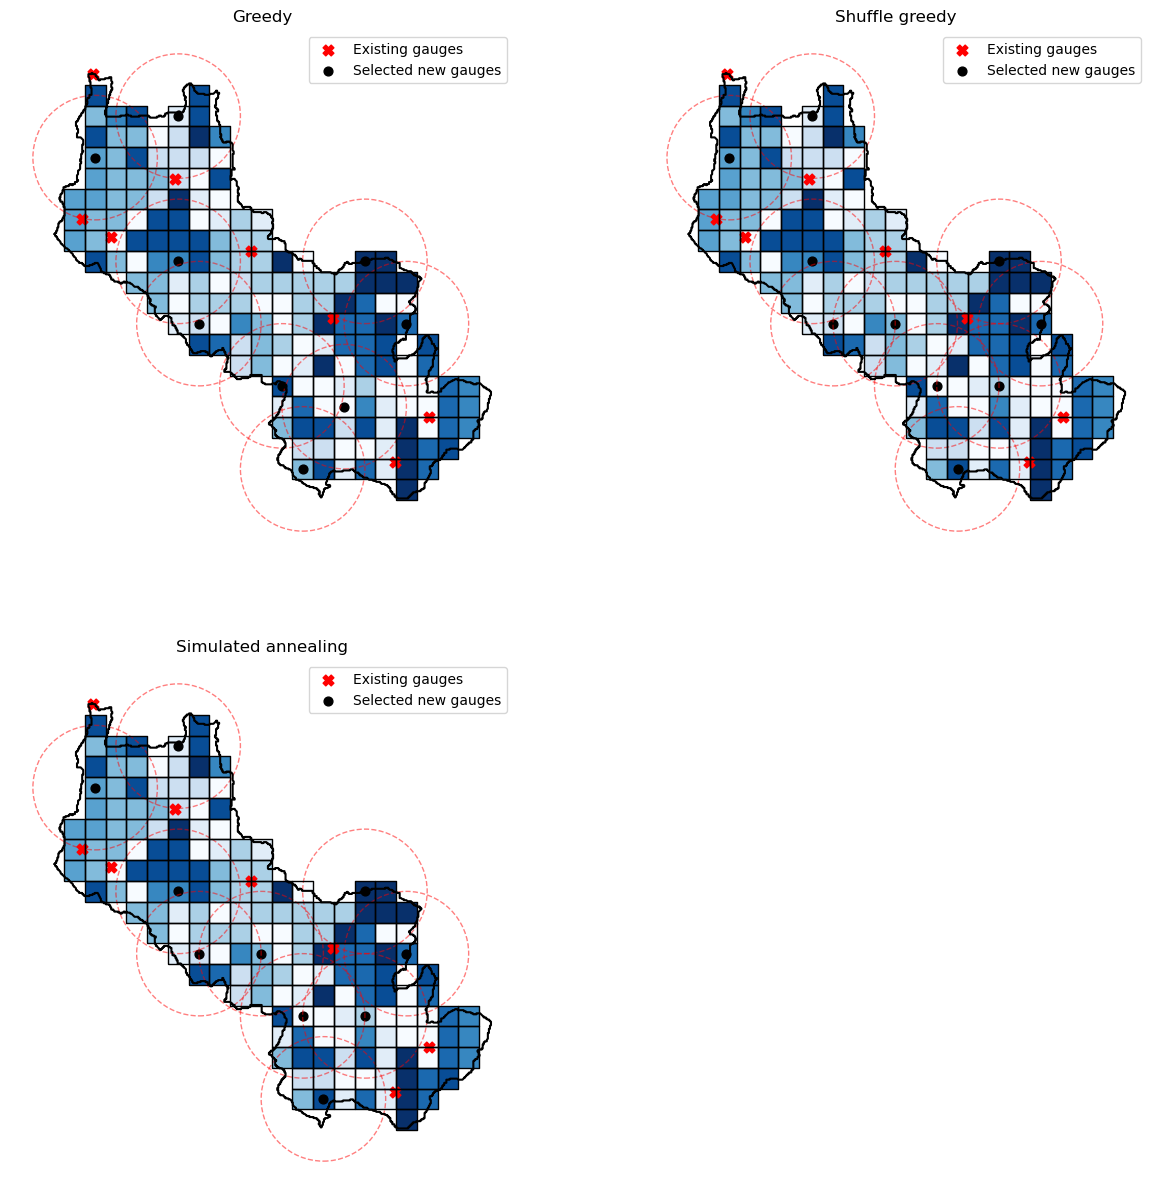

In [19]:
# PLOT
fig,axs=plt.subplots(ncols=2, nrows=2, figsize=(15,15))
axs=axs.flatten()

# #print("\n--- GREEDY ---")
plot_and_check(rainfall_gdf_merged, greedy_solution, cell_centroids, catchment_Dolwen, existing_coords, min_dist, 'Greedy',
               ax=axs[0])
axs[0].axis('off');

#print("\n--- SHUFFLE GREEDY ---")
plot_and_check(rainfall_gdf_merged, shuffle_solution, cell_centroids, catchment_Dolwen, existing_coords, min_dist, 
               'Shuffle greedy', ax=axs[1])
axs[1].axis('off');

#print("\n--- Simulated annealing ---")
plot_and_check(rainfall_gdf_merged, sa_solution, cell_centroids, catchment_Dolwen,  existing_coords, min_dist, 
               'Simulated annealing', ax=axs[2])
axs[2].axis('off');

# #print("\n--- ILP ---")
# #plot_and_check(rainfall_gdf_merged, ilp_solution_result, cell_centroids, existing_coords, min_dist, ax=axs[3])
axs[3].axis('off');
# axs[3].set_axis_off()


<div style="background-color: lightblue; color: black;  border: 2px solid black; padding: 15px 20px; border-radius: 5px; margin: 10px 0px;"><h3 style="color: black; margin: 0px;"> oPTIONS </h3>
    
 - Add rainfall data to cluster analysis
 - Use HAD-UK daily and then try and work out which locations in catchment are underpredicted?
    
  </div>    
</div>

In [21]:
# Get HAD-UK rainfall values at existing gauge locations
from rasterstats import point_query

# Extract mean annual rainfall at each existing gauge location
gauge_x = xr.DataArray(existing_coords[:, 0], dims="points")
gauge_y = xr.DataArray(existing_coords[:, 1], dims="points")

gauge_rainfall = HAD_Dolwen_ppn_mean.sel(projection_x_coordinate=gauge_x,projection_y_coordinate=gauge_y,
                                         method="nearest").values

print(gauge_rainfall)

gauge_rainfall = np.array(gauge_rainfall, dtype=float)

[1969.60052116 1410.05261377 2905.09448423 2461.29904364 1717.6304151
 1230.73176895 1295.25672508 1935.92744785]


In [23]:
for i, (val, coord) in enumerate(zip(gauge_rainfall, existing_coords)):
    print(f"Gauge {i}: coords {coord}, rainfall {val:.1f} mm")

Gauge 0: coords [287337.518 290457.408], rainfall 1969.6 mm
Gauge 1: coords [297934.427 276846.549], rainfall 1410.1 mm
Gauge 2: coords [282880.59  288538.431], rainfall 2905.1 mm
Gauge 3: coords [284280.55 287687.34], rainfall 2461.3 mm
Gauge 4: coords [291003.558 286996.319], rainfall 1717.6 mm
Gauge 5: coords [299606.62  279023.643], rainfall 1230.7 mm
Gauge 6: coords [294944.369 283794.594], rainfall 1295.3 mm
Gauge 7: coords [283398. 295527.], rainfall 1935.9 mm


In [26]:
x_coords = HAD_Dolwen_ppn_mean.projection_x_coordinate.values
y_coords = HAD_Dolwen_ppn_mean.projection_y_coordinate.values

xx, yy = np.meshgrid(x_coords, y_coords)
x_flat = xx.flatten()
y_flat = yy.flatten()
rainfall_flat = HAD_Dolwen_ppn_mean.values.flatten()

# Remove NaNs
valid = ~np.isnan(rainfall_flat)
x_flat = x_flat[valid]
y_flat = y_flat[valid]
rainfall_flat = rainfall_flat[valid]

#### Fit a variogram using HAD-UK data across the whole catchment

In [27]:
from scipy.spatial.distance import pdist, squareform
from scipy.optimize import curve_fit

# Calculate pairwise distances between all HAD-UK points
coords = np.column_stack([x_flat, y_flat])
distances = pdist(coords)
# Calculate pairwise squared differences in rainfall
rainfall_diff = pdist(rainfall_flat.reshape(-1, 1), 
                      metric=lambda u, v: 0.5 * (u - v) ** 2)

# Bin the semivariances by distance
n_bins = 20
max_dist = 50000  # 50km - adjust based on catchment size
bin_edges = np.linspace(0, max_dist, n_bins + 1)
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

gamma = np.zeros(n_bins)
counts = np.zeros(n_bins)

for i in range(n_bins):
    mask = (distances >= bin_edges[i]) & (distances < bin_edges[i+1])
    if mask.sum() > 0:
        gamma[i] = rainfall_diff[mask].mean()
        counts[i] = mask.sum()

# Remove empty bins
valid_bins = counts > 0
bin_centers = bin_centers[valid_bins]
gamma = gamma[valid_bins]

In [28]:
# Define exponential variogram model
# nugget = variance at zero distance (measurement error)
# sill = plateau variance
# range_ = distance at which correlation dies out
def exponential_variogram(h, nugget, sill, range_):
    return nugget + (sill - nugget) * (1 - np.exp(-h / range_))

# Fit to empirical variogram
# Initial guesses for parameters
p0 = [
    gamma.min(),           # nugget
    gamma.max(),           # sill  
    max_dist / 3           # range
]

params, _ = curve_fit(
    exponential_variogram,
    bin_centers,
    gamma,
    p0=p0,
    bounds=(0, np.inf)  # all parameters must be positive
)

nugget, sill, range_ = params
print(f"Nugget: {nugget:.1f}")
print(f"Sill: {sill:.1f}")
print(f"Range: {range_:.1f} m")

Nugget: 0.0
Sill: 455621.4
Range: 14757.9 m


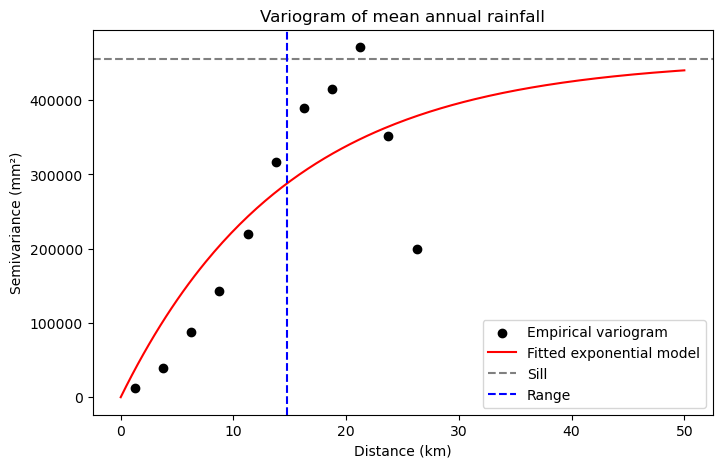

In [29]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(bin_centers/1000, gamma, label='Empirical variogram', 
           color='black', zorder=5)
h_plot = np.linspace(0, max_dist, 200)
ax.plot(h_plot/1000, 
        exponential_variogram(h_plot, nugget, sill, range_),
        color='red', label='Fitted exponential model')
ax.axhline(sill, color='grey', linestyle='--', label='Sill')
ax.axvline(range_/1000, color='blue', linestyle='--', label='Range')
ax.set_xlabel('Distance (km)')
ax.set_ylabel('Semivariance (mm²)')
ax.set_title('Variogram of mean annual rainfall')
ax.legend()
plt.show()

In [30]:
def kriging_variance(pred_points, cond_points, nugget, sill, range_):
    """
    Calculate kriging variance at prediction points
    given conditioning points (existing gauges)
    """
    n = len(cond_points)
    variances = np.zeros(len(pred_points))
    
    # Build covariance matrix between conditioning points
    C = np.zeros((n + 1, n + 1))
    for i in range(n):
        for j in range(n):
            h = np.linalg.norm(cond_points[i] - cond_points[j])
            # Covariance = sill - variogram
            C[i, j] = sill - exponential_variogram(h, nugget, sill, range_)
    # Add Lagrange multiplier row/col for ordinary kriging
    C[:n, n] = 1
    C[n, :n] = 1
    C[n, n] = 0
    
    # For each prediction point
    for k, pred in enumerate(pred_points):
        # Build covariance vector between pred point and gauges
        c = np.zeros(n + 1)
        for i in range(n):
            h = np.linalg.norm(pred - cond_points[i])
            c[i] = sill - exponential_variogram(h, nugget, sill, range_)
        c[n] = 1  # Lagrange multiplier
        
        # Solve kriging system
        try:
            weights = np.linalg.solve(C, c)
            # Kriging variance
            variances[k] = sill - np.dot(weights, c)
        except np.linalg.LinAlgError:
            variances[k] = np.nan
            
    return variances

# Calculate variance at all HAD-UK grid cells
pred_points = np.column_stack([x_flat, y_flat])
cond_points = existing_coords

variance = kriging_variance(pred_points, cond_points, 
                            nugget, sill, range_)

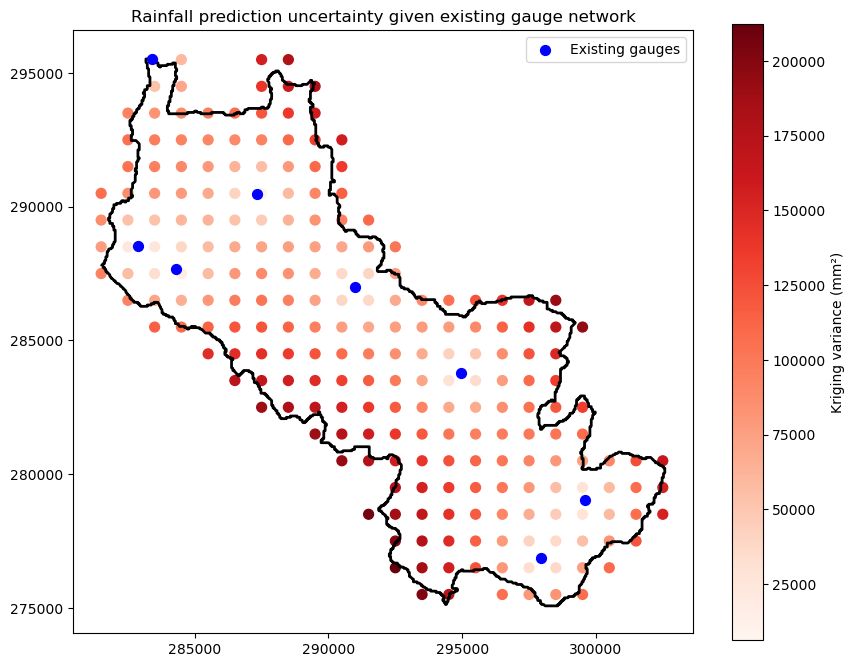

In [33]:
# Create a dataframe of coordinates and variance values
variance_df = pd.DataFrame({
    'x': x_flat,
    'y': y_flat,
    'kriging_variance': variance
})

# Round coordinates to match your grid (avoids floating point mismatches)
variance_df['x'] = variance_df['x'].round(-2)  # round to nearest 100m
variance_df['y'] = variance_df['y'].round(-2)

# Do the same for your grid centroids
rainfall_gdf_merged['x_centroid'] = rainfall_gdf_merged.geometry.centroid.x.round(-2)
rainfall_gdf_merged['y_centroid'] = rainfall_gdf_merged.geometry.centroid.y.round(-2)

# Merge variance onto grid
rainfall_gdf_merged = rainfall_gdf_merged.merge(
    variance_df,
    left_on=['x_centroid', 'y_centroid'],
    right_on=['x', 'y'],
    how='left'
)

# Plot as grid cells
fig, ax = plt.subplots(figsize=(10, 8))
rainfall_gdf_merged.plot(
    column='kriging_variance',
    cmap='Reds',
    legend=True,
    ax=ax,
    legend_kwds={'label': 'Kriging variance (mm²)'}
)
existing_gauges.plot(
    ax=ax,
    color='blue',
    markersize=50,
    label='Existing gauges',
    zorder=5
)
catchment_Dolwen.boundary.plot(
    ax=ax,
    color='black',
    linewidth=2
)
ax.set_title('Rainfall prediction uncertainty given existing gauge network')
plt.legend()
plt.show()

In [40]:
import gstools as gs

# Get all HAD-UK cell centroids and rainfall values within catchment
# haduk_coords = np.array([(g.x, g.y) for g in rainfall_gdf_merged.geometry])

haduk_coords = np.array([
    (geom.centroid.x, geom.centroid.y)
    for geom in rainfall_gdf_merged.geometry
])

haduk_rainfall = rainfall_gdf_merged['rainfall'].values

# Fit variogram to HAD-UK data
x, y = haduk_coords[:, 0], haduk_coords[:, 1]

# Fit an exponential variogram model
bin_center, gamma = gs.vario_estimate(
    (x, y),
    haduk_rainfall,
    bin_edges=np.linspace(0, 50000, 20)  # bins in metres
)

# Fit model to empirical variogram
fit_model = gs.Exponential(dim=2)
fit_model.fit_variogram(bin_center, gamma)
print(fit_model)

Exponential(dim=2, var=2.38e-26, len_scale=1e+05, nugget=1.38e+04)


In [41]:
# Set up universal kriging conditioned on existing gauges
krige = gs.krige.Universal(
    model=fit_model,
    cond_pos=(existing_coords[:, 0], existing_coords[:, 1]),
    cond_val=gauge_rainfall,
    drift_functions="linear"  # accounts for spatial trend
)

# Calculate variance at every HAD-UK grid cell centroid
grid_x = haduk_coords[:, 0]
grid_y = haduk_coords[:, 1]

_, variance = krige((grid_x, grid_y), return_var=True)

# Add variance back to your GeoDataFrame
rainfall_gdf_merged['kriging_variance'] = variance

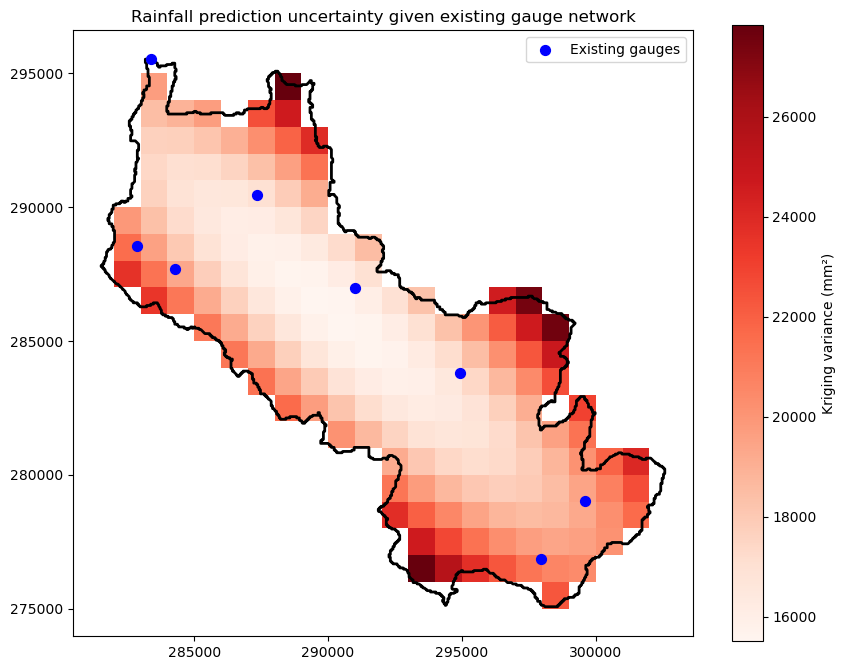

In [43]:
fig, ax = plt.subplots(figsize=(10, 8))
rainfall_gdf_merged.plot(
    column='kriging_variance',
    cmap='Reds',
    legend=True,
    ax=ax,
    legend_kwds={'label': 'Kriging variance (mm²)'}
)
existing_gauges.plot(ax=ax, color='blue', markersize=50, 
                     label='Existing gauges', zorder=5)
catchment_Dolwen.plot(ax=ax, color='none', 
                        edgecolor='black', linewidth=2)
ax.set_title('Rainfall prediction uncertainty given existing gauge network')
plt.legend()
plt.show()